In [ ]:
%pip install pandas numpy seaborn matplotlib scipy pydeseq2 gprofiler-official adjustText
!rm -drf Data
!mkdir Data
!curl https://raw.githubusercontent.com/simonelsasser/SP1-01-Ex/f048b4557e63417354839094bf812fd808a67dde/Kumar_NCB/Data/metaData.csv -o Data/metaData.csv
!curl https://raw.githubusercontent.com/simonelsasser/SP1-01-Ex/f048b4557e63417354839094bf812fd808a67dde/Kumar_NCB/Data/rsem.merged.gene_counts_2021.tsv -o Data/rsem.merged.gene_counts_2021.tsv
!curl https://raw.githubusercontent.com/simonelsasser/SP1-01-Ex/f048b4557e63417354839094bf812fd808a67dde/Kumar_NCB/Data/gene_group_mapping.csv -o Data/gene_group_mapping.csv
!ls Data/
!cat Data/metaData.csv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 108.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 7.0 MB/s eta 0:00:00
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   633  100   633    0     0   5377      0 --:--:-- --:--:-- --:--:--  5410
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 2587k  100 2587k    0     0  23.8M  

In [2]:
import pandas as pd
import numpy as np

#########################
######   TASK 1   #######
#      read in data     #
#########################

file_path = "Data/rsem.merged.gene_counts_2021.tsv"
# Read in count file "Data/rsem.merged.gene_counts_2021.tsv", it is a tab-separated file with the first column as index
count_table = pd.read_csv(file_path, sep='\t', index_col=0)
# Print the first 5 rows of the count table
print(count_table.head())

                                           transcript_id(s)  Naive_EZH2i_R1  \
gene_id                                                                       
A1BG                                              NM_130786             3.0   
A1BG-AS1                                          NR_015380             7.0   
A1CF      NM_001198818,NM_001198819,NM_001198820,NM_0145...             0.0   
A2M                                               NM_000014             1.0   
A2M-AS1                                           NR_026971             0.0   

          Naive_EZH2i_R2  Naive_EZH2i_R3  Naive_R1  Naive_R2  Naive_R3  \
gene_id                                                                  
A1BG                 4.0             6.0       2.0       0.0       4.0   
A1BG-AS1             4.0             5.0       2.0       3.0       2.0   
A1CF                 0.0             0.0       0.0       0.0       0.0   
A2M                  1.0             1.0       0.0       0.0       0.0   
A2

In [3]:

# we are going to remove 'transcript_id(s)' from the count table, as they are not needed for the analysis
count_table = count_table.drop('transcript_id(s)', axis=1)
# Print the head again
print(count_table.head())


          Naive_EZH2i_R1  Naive_EZH2i_R2  Naive_EZH2i_R3  Naive_R1  Naive_R2  \
gene_id                                                                        
A1BG                 3.0             4.0             6.0       2.0       0.0   
A1BG-AS1             7.0             4.0             5.0       2.0       3.0   
A1CF                 0.0             0.0             0.0       0.0       0.0   
A2M                  1.0             1.0             1.0       0.0       0.0   
A2M-AS1              0.0             0.0             0.0       0.0       0.0   

          Naive_R3  Primed_EZH2i_R1  Primed_EZH2i_R2  Primed_EZH2i_R3  \
gene_id                                                                 
A1BG           4.0            137.0            175.0            143.0   
A1BG-AS1       2.0             36.0             28.0             28.0   
A1CF           0.0              2.0              0.0              0.0   
A2M            0.0            143.0            114.0            112.0   
A

In [4]:
#Check the numbers in the count table - it looks like they are all intergers. Is this what you expect?

#Let's take the first column (Naive_EZH2i_R1)- What is the min, max, mean, median and variance of the counts in the count table? 
print("Min:", count_table.iloc[:, 0].min())
print("Max:", count_table.iloc[:, 0].max())
print("Mean:", count_table.iloc[:, 0].mean())
print("Median:", np.median(count_table.iloc[:, 0]))
print("Variance:", np.var(count_table.iloc[:, 0]))
print("Number of zeros:", np.sum(count_table.iloc[:, 0] == 0))

# Are there any zeros? How many genes in total and how many genes have zero counts in all samples?
print("Total number of genes:", count_table.shape[0])
print("Number of genes with zero counts in all samples:", np.sum(np.all(count_table.values == 0, axis=1)))

Min: 0.0
Max: 76778.0
Mean: 84.87063229461758
Median: 3.0
Variance: 379818.61545530043
Number of zeros: 10968
Total number of genes: 26475
Number of genes with zero counts in all samples: 6044


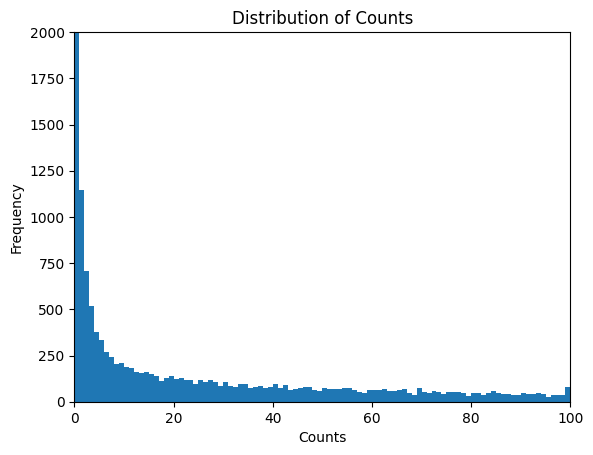

In [5]:

# What is the distribution of counts? Can you make a graph to inspect the distribution? 
import matplotlib.pyplot as plt

# Plot a histogram of the counts in the first column, limit the x axis to 0-100 and set the bin width to 10
# What do you observe? What does the high peak at zero and long tail mean?
plt.hist(count_table.iloc[:, 0], bins=100, range=(0, 100))
plt.xlabel('Counts')
plt.ylabel('Frequency')
plt.title('Distribution of Counts')
plt.xlim(0, 100)
plt.ylim(0, 2000)
plt.show()

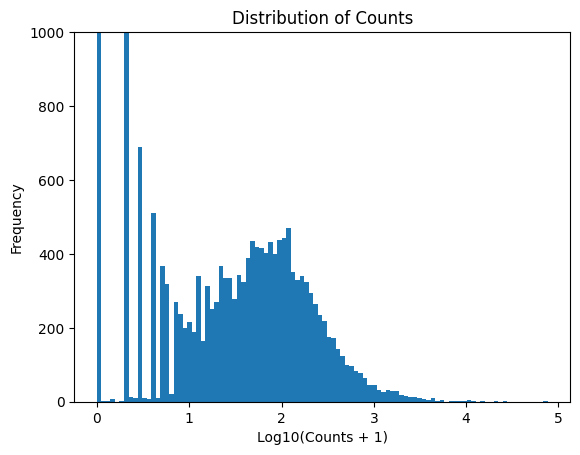

In [6]:
# Let's try to log transform the counts with log10 (add + 1 to the count table to avoid log(0)!)
plt.hist(np.log10(count_table.iloc[:, 0]+1), bins=100)
plt.xlabel('Log10(Counts + 1)')
plt.ylabel('Frequency')
plt.title('Distribution of Counts')
plt.ylim(0, 1000)
plt.show()

In [7]:
# For comparing gene expression, we need to understand the distribution of read counts not within one sample, but for each gene across all samples. Let's plot the distribution of counts the pluripotency factor gene NANOG and GAPDH (housekeeping gene)across all samples. What do you observe?
print(count_table.loc['NANOG', :])
print(count_table.loc['GAPDH', :])


Naive_EZH2i_R1      103.0
Naive_EZH2i_R2       82.0
Naive_EZH2i_R3       79.0
Naive_R1            778.0
Naive_R2            770.0
Naive_R3            804.0
Primed_EZH2i_R1    1541.0
Primed_EZH2i_R2    1418.0
Primed_EZH2i_R3    1411.0
Primed_R1          1214.0
Primed_R2          1124.0
Primed_R3          1183.0
Name: NANOG, dtype: float64
Naive_EZH2i_R1       8707.0
Naive_EZH2i_R2       9111.0
Naive_EZH2i_R3       8525.0
Naive_R1            10536.0
Naive_R2             9876.0
Naive_R3            10762.0
Primed_EZH2i_R1    111974.0
Primed_EZH2i_R2    125424.0
Primed_EZH2i_R3    102649.0
Primed_R1          111263.0
Primed_R2          111576.0
Primed_R3          125533.0
Name: GAPDH, dtype: float64


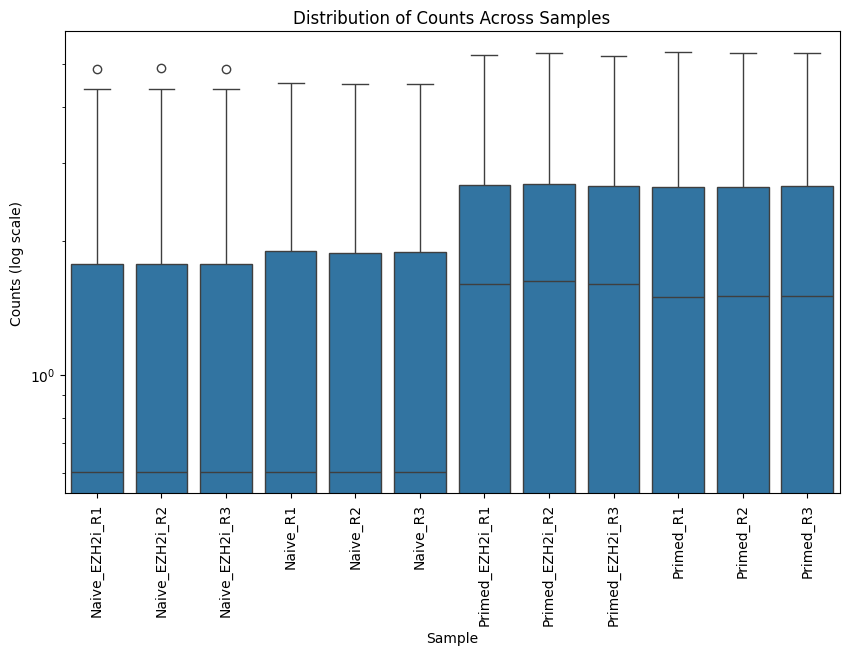

In [8]:
# Now something looks strange - the counts for "Primed" appear to be much higher even for housekeeping gene GAPDH. Let's plot the distribution of counts for all samples and see if we can spot any batch effect or other technical bias. We can use a box plot for this.
import seaborn as sns
# Convert the count table to long format for seaborn box plot and log transform
count_table_long = count_table.melt(var_name='Sample', value_name='Count')
count_table_long['Count'] = np.log10(count_table_long['Count'] + 1)
# Plot a box plot of counts for each sample
plt.figure(figsize=(10, 6))
sns.boxplot(x='Sample', y='Count', data=count_table_long)
plt.yscale('log')
plt.xlabel('Sample')
plt.ylabel('Counts (log scale)')
plt.title('Distribution of Counts Across Samples')
plt.xticks(rotation=90)
plt.show()

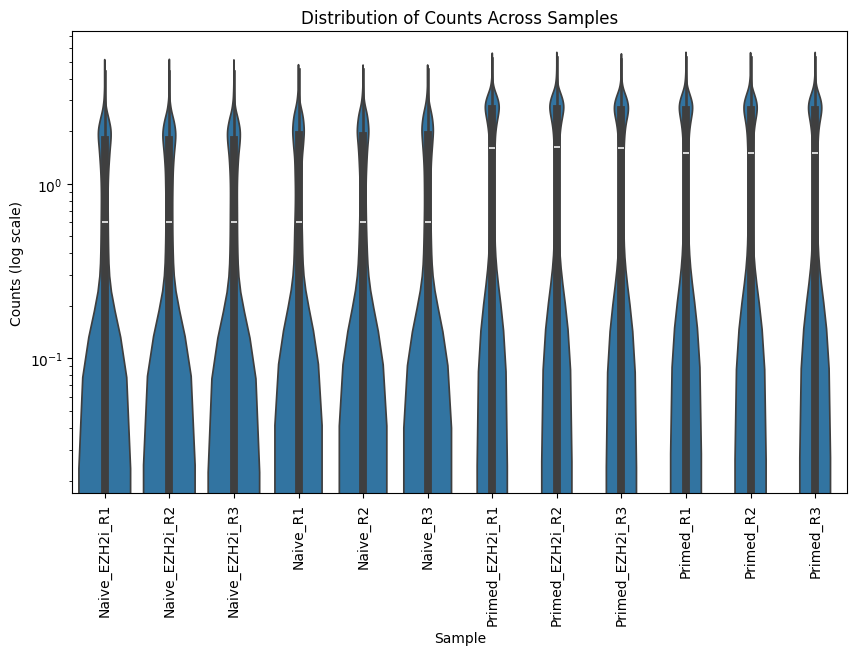

In [9]:

# Since we learned that boxplots could hide the distribution of the data, let's try a violin plot instead
# Plot a violin plot of counts for each sample
plt.figure(figsize=(10, 6))
sns.violinplot(x='Sample', y='Count', data=count_table_long)
plt.yscale('log')
plt.xlabel('Sample')
plt.ylabel('Counts (log scale)')
plt.title('Distribution of Counts Across Samples')
plt.xticks(rotation=90)
plt.show()

In [10]:
# Clearly there is a big difference between the "Naive" and "Primed" samples
# A trivial source of this difference is that libraries are sequenced to different depths, this happens because it is difficult to exactly normalize the NGS library
# before sequencing
# In the current dataset, the BGI generated almost exactly the same sequencing depth. But we actually know why there is a sytematic different:
# The "Naive" cells are grown on mouse feader cells, so in the RNA extraction
# we have a big contribution of mouse RNA, this will be part of the library but it will not map to the human genome. So a lot of the reads in the library are 'lost' to mouse RNA,
# and as a result we appear to have less total reads.

# In order to compare gene expression between the "Naive" and "Primed" samples, we need to normalize the counts to account for this difference in sequencing depth. One common way to do this is to calculate counts per million (CPM) or transcripts per million (TPM). Let's calculate CPM for each sample and plot the distribution again.
# Calculate CPM: Normalize each row count by the total read count of the sample (column sum) and multiply by 1 million
cpm_table = count_table.div(count_table.sum(axis=0), axis=1) * 1e6
# now check NANOG and GAPDH again
print(cpm_table.loc['NANOG', :])
print(cpm_table.loc['GAPDH', :])

Naive_EZH2i_R1      45.839917
Naive_EZH2i_R2      36.234815
Naive_EZH2i_R3      35.005953
Naive_R1           250.617446
Naive_R2           253.871128
Naive_R3           256.065715
Primed_EZH2i_R1    103.559824
Primed_EZH2i_R2     90.107487
Primed_EZH2i_R3     98.619887
Primed_R1           81.683712
Primed_R2           75.276751
Primed_R3           77.185017
Name: NANOG, dtype: float64
Naive_EZH2i_R1     3875.030614
Naive_EZH2i_R2     4026.041502
Naive_EZH2i_R3     3777.541155
Naive_R1           3393.965822
Naive_R2           3256.144498
Naive_R3           3427.586102
Primed_EZH2i_R1    7524.988819
Primed_EZH2i_R2    7970.128003
Primed_EZH2i_R3    7174.509404
Primed_R1          7486.305485
Primed_R2          7472.490013
Primed_R3          8190.419876
Name: GAPDH, dtype: float64


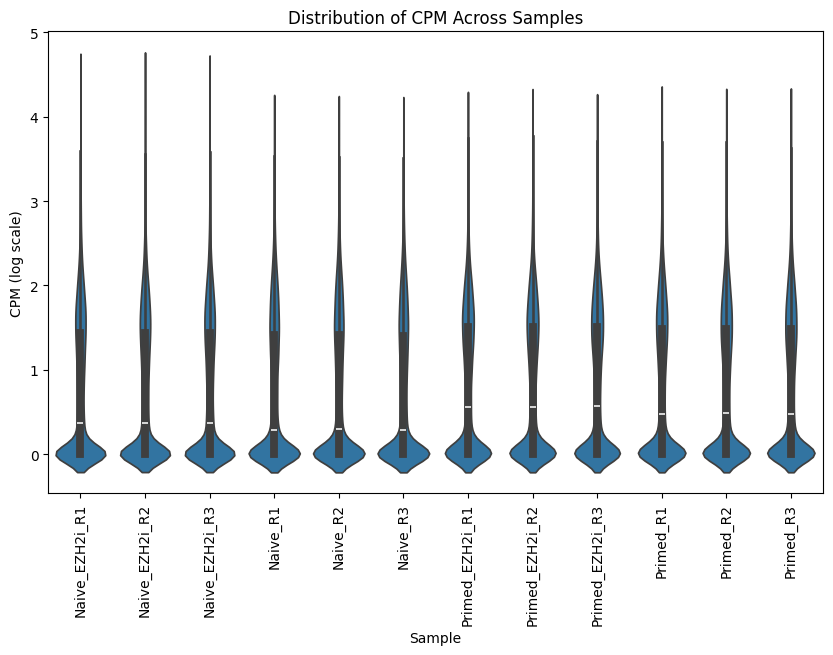

In [11]:

# Convert to long format for plotting and log transform 
cpm_table_long = cpm_table.melt(var_name='Sample', value_name='CPM')
cpm_table_long['CPM'] = np.log10(cpm_table_long['CPM'] + 1)
# Plot a violin plot of CPM for each sample
plt.figure(figsize=(10, 6))
sns.violinplot(x='Sample', y='CPM', data=cpm_table_long)
plt.xlabel('Sample')
plt.ylabel('CPM (log scale)')
plt.title('Distribution of CPM Across Samples')
plt.xticks(rotation=90)
plt.show()

In [12]:
# Great, now the "Naive" and "Primed" samples look much more similar, we can now compare gene expression between them!
### WARNING: CPM is not a good normalization method for differential expression analysis, because it is highly skewed by the largest counts in the table (the tail)
# Better would be to align the distributions, e.g. by minimizing the variance of the log fold changes between samples, this is what DESeq2 does with its size factor estimation. We will learn about this in the next session.
# But you can see that for now CPM works quite OK for the given data

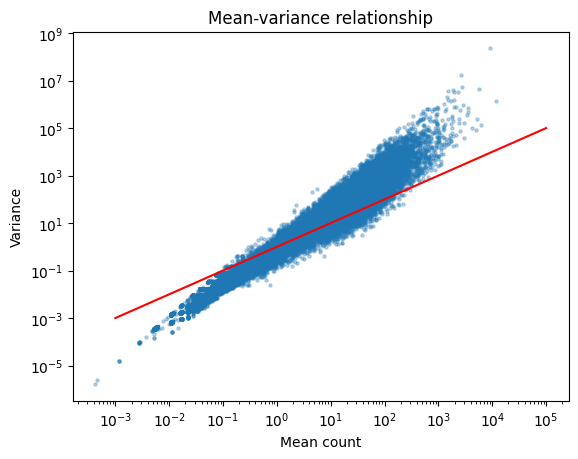

In [13]:
## DESeq2 works under the assumption of a negative binomial distribution, which means that the variance should be higher than the mean. 
# This is an empirical observation that holds for most genes in RNA-seq data, and it is one of the reasons why DESeq2 uses a negative binomial distribution to model the counts.
# The alternative model wpuld be the Poisson distribution, which assumes that the variance is equal to the mean. 
# Let's check if this is true for our data by plotting the mean-variance relationship of the CPM values.
means = cpm_table.mean(axis=1)
vars_ = cpm_table.var(axis=1)

plt.scatter(means, vars_, s=5, alpha=0.3)
plt.xscale("log")
plt.yscale("log")

plt.xlabel("Mean count")
plt.ylabel("Variance")
plt.title("Mean-variance relationship")
x = np.logspace(-3, 5, 100)
plt.plot(x, x, color="red", label="Poisson variance")
plt.show()


In [14]:
# Read in file 
experiment_design = pd.read_csv("Data/metaData.csv", sep=",")

# Get an overview of the file
print(experiment_design)

       BioSample          SRR condition treatment             Name
0   SAMN25076933  SRR17657871     naive      none         Naive_R1
1   SAMN25076934  SRR17657872     naive      none         Naive_R2
2   SAMN25076935  SRR17657873     naive      none         Naive_R3
3   SAMN25076936  SRR17657874     naive     EZH2i   Naive_EZH2i_R1
4   SAMN25076938  SRR17657875     naive     EZH2i   Naive_EZH2i_R2
5   SAMN25076939  SRR17657876     naive     EZH2i   Naive_EZH2i_R3
6   SAMN25076940  SRR17657877    primed      none        Primed_R1
7   SAMN25076941  SRR17657878    primed      none        Primed_R2
8   SAMN25076942  SRR17657879    primed      none        Primed_R3
9   SAMN25076943  SRR17657880    primed     EZH2i  Primed_EZH2i_R1
10  SAMN25076944  SRR17657881    primed     EZH2i  Primed_EZH2i_R2
11  SAMN25076945  SRR17657882    primed     EZH2i  Primed_EZH2i_R3


In [15]:
#########################
######   TASK 2   #######
# Preparation for DESeq #
#########################

# prepare metaData
# shape meta for DESeq analysis (name as index, treatment and condition as column)
meta = experiment_design.set_index("Name")
#meta = meta[["treatment","condition"]]
# shape meta for DESeq analysis (name as index, treatment and condition as column)
# add a column "design" that is a combination of treatment and condition, e.g. "Naive_EZH2i" and "Primed_EZH2i"
meta["design"] = meta["condition"] + "_" + meta["treatment"]
print(meta)

                    BioSample          SRR condition treatment        design
Name                                                                        
Naive_R1         SAMN25076933  SRR17657871     naive      none    naive_none
Naive_R2         SAMN25076934  SRR17657872     naive      none    naive_none
Naive_R3         SAMN25076935  SRR17657873     naive      none    naive_none
Naive_EZH2i_R1   SAMN25076936  SRR17657874     naive     EZH2i   naive_EZH2i
Naive_EZH2i_R2   SAMN25076938  SRR17657875     naive     EZH2i   naive_EZH2i
Naive_EZH2i_R3   SAMN25076939  SRR17657876     naive     EZH2i   naive_EZH2i
Primed_R1        SAMN25076940  SRR17657877    primed      none   primed_none
Primed_R2        SAMN25076941  SRR17657878    primed      none   primed_none
Primed_R3        SAMN25076942  SRR17657879    primed      none   primed_none
Primed_EZH2i_R1  SAMN25076943  SRR17657880    primed     EZH2i  primed_EZH2i
Primed_EZH2i_R2  SAMN25076944  SRR17657881    primed     EZH2i  primed_EZH2i

In [16]:
# prepare count table 
# filter for lowly expressed genes
genes_to_keep = count_table.columns[count_table.sum(axis=0) >= 10]
counts_df = count_table[genes_to_keep]

# convert dataframe to integer
counts_df = counts_df.astype(int)

# transpose dataframe for Deseq analysis
counts_df = counts_df.T

# tricky part: make sure that the order of samples in the count table matches the order of samples in the meta data, otherwise DESeq2 will throw an error. 
# We can do this by reindexing the count table with the index of the meta data.
print(counts_df.index)
counts_df = counts_df.loc[meta.index]
print(counts_df.index)

Index(['Naive_EZH2i_R1', 'Naive_EZH2i_R2', 'Naive_EZH2i_R3', 'Naive_R1',
       'Naive_R2', 'Naive_R3', 'Primed_EZH2i_R1', 'Primed_EZH2i_R2',
       'Primed_EZH2i_R3', 'Primed_R1', 'Primed_R2', 'Primed_R3'],
      dtype='object')
Index(['Naive_R1', 'Naive_R2', 'Naive_R3', 'Naive_EZH2i_R1', 'Naive_EZH2i_R2',
       'Naive_EZH2i_R3', 'Primed_R1', 'Primed_R2', 'Primed_R3',
       'Primed_EZH2i_R1', 'Primed_EZH2i_R2', 'Primed_EZH2i_R3'],
      dtype='object', name='Name')


In [17]:
#######################
######   TASK 3   #######
#     Running DESeq2    #
#########################

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

# create DeseqDataSet
dds = DeseqDataSet(
    counts=counts_df,
    metadata=meta,
    design="~design",
    refit_cooks=True)


In [18]:
# run dds.deseq2()
dds.deseq2()

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 21.03 seconds.

Fitting dispersion trend curve...
... done in 0.38 seconds.

Fitting MAP dispersions...
... done in 19.23 seconds.

Fitting LFCs...
... done in 11.74 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 0 outlier genes.



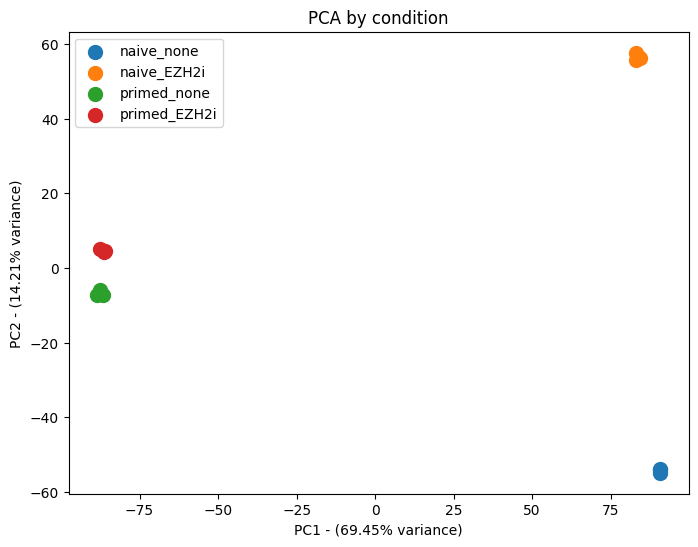

In [114]:
#extract and log transform the normalized counts for PCA, it is stored in dds.layers["normed_counts"], a samples x genes matrix
lnc = np.log1p(dds.layers["normed_counts"])  # samples x genes
 
# Basic PCA with scikit-learn
from importlib.metadata import metadata

from sklearn.decomposition import PCA
 
X = np.asarray(lnc)                         # make sure it's a numeric array
pca_model = PCA(n_components=2)
pca = pca_model.fit_transform(X)  # PCs across samples
 
# Plot, color by design, provide legend and labels of points
# add the variability explained by the PCs in the axis labels
plt.figure(figsize=(8, 6))
for design in meta["design"].unique():
    mask = meta["design"] == design
    plt.scatter(pca[mask, 0], pca[mask, 1], label=design, marker="o", s=100)

plt.xlabel(f"PC1 - ({pca_model.explained_variance_ratio_[0]:.2%} variance)")
plt.ylabel(f"PC2 - ({pca_model.explained_variance_ratio_[1]:.2%} variance)")
plt.title("PCA by condition")
plt.legend()
plt.show()

In [49]:
# output the top genes that contribute to PC1 and PC2, i.e. the genes with the highest absolute loadings in the PCA model
loadings = pca_model.components_.T  # genes x PCs
loading_df = pd.DataFrame(loadings, index=counts_df.columns, columns=[f"PC{i+1}" for i in range(loadings.shape[1])])
# get the top 10 genes for PC1 and PC2
top_genes_pc1 = loading_df["PC1"].abs().sort_values(ascending=False).head(20)
top_genes_pc2 = loading_df["PC2"].abs().sort_values(ascending=False).head(20)
print("Top genes contributing to PC1:")
print(top_genes_pc1)
print("\nTop genes contributing to PC2:")
print(top_genes_pc2)
#save those in pca_genes
pca_genes = list(top_genes_pc1.index) + list(top_genes_pc2.index)

Top genes contributing to PC1:
gene_id
COL3A1       0.049452
DNMT3L       0.045072
LUM          0.042029
KHDC1L       0.040621
XIST         0.038618
NLRP7        0.037604
H19          0.037465
KHDC3L       0.036979
FAM151A      0.036761
ZNF729       0.036361
FEZF1        0.036300
ZNF208       0.036135
HAND1        0.036056
DPPA5        0.035926
ATP1A2       0.035808
MAEL         0.034787
EGR1         0.034756
PEG3         0.034666
FEZF1-AS1    0.034196
LCP1         0.034071
Name: PC1, dtype: float64

Top genes contributing to PC2:
gene_id
IGF2       0.043792
RELN       0.043354
SLC18A3    0.041877
MGP        0.040593
COL15A1    0.040253
DCN        0.040015
ALDH1A2    0.037915
EDNRA      0.037635
GNG11      0.037612
TNNT2      0.037273
REN        0.036396
RGPD8      0.036024
SPOCK1     0.036018
FMN2       0.035889
PGM5       0.035395
KRT23      0.035309
SLFN11     0.035284
SLC13A4    0.035054
EIF3CL     0.034760
MAB21L1    0.034386
Name: PC2, dtype: float64


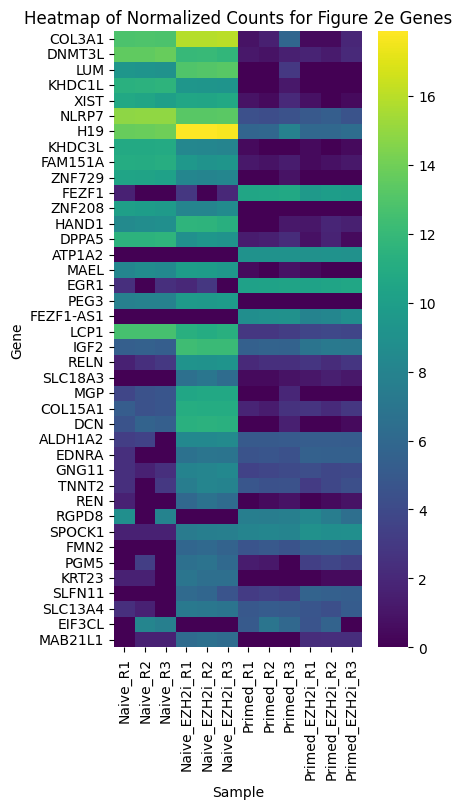

In [50]:

#from normed_counts_long, subset for the genes in genes_2e and plot a heatmap of the normalized counts for these genes across the samples, group by design
normed_counts_log = normed_counts.reset_index().melt(id_vars=["Name"], var_name="gene_id", value_name="normalized_count")
normed_counts_log["normalized_count"] = np.log2(normed_counts_log["normalized_count"]+1)
normed_counts_log["design"] = normed_counts_log["Name"].map(meta["design"])
normed_counts_2e = normed_counts_log[normed_counts_log["gene_id"].isin(pca_genes)]
normed_counts_2e_pivot = normed_counts_2e.pivot(index="gene_id", columns="Name", values="normalized_count")
# reindex to maintain the original order from genes_2e
normed_counts_2e_pivot = normed_counts_2e_pivot.reindex(pca_genes)
# sort columns by design order: naive_none, naive_EZH2i, primed_none, primed_EZH2i
design_order = ["naive_none","naive_EZH2i","primed_none","primed_EZH2i"]
sorted_columns = sorted(normed_counts_2e_pivot.columns, 
                       key=lambda x: (design_order.index(meta.loc[x, "design"]), x))
normed_counts_2e_pivot = normed_counts_2e_pivot[sorted_columns]
# plot a heatmap of the normalized counts for these genes across the samples, group by design
plt.figure(figsize=(4, 8))
sns.heatmap(normed_counts_2e_pivot, cmap="viridis", yticklabels=True)
plt.title("Heatmap of Normalized Counts for Figure 2e Genes")
plt.xlabel("Sample")
plt.ylabel("Gene")
plt.xticks(rotation=90)
plt.show()


In [106]:

# output the top genes that contribute to PC1 and PC2, i.e. the genes with the highest absolute loadings in the PCA model
loadings = pca_model.components_.T  # genes x PCs
loading_df = pd.DataFrame(loadings, index=counts_df.columns, columns=[f"PC{i+1}" for i in range(loadings.shape[1])])
# get the top 10 genes for PC1 and PC2
pc2_top_up = loading_df["PC2"].sort_values(ascending=False).head(100).copy()
pc2_top_down = loading_df["PC2"].sort_values(ascending=False).tail(100).copy()

print(pc2_top_up.head(10))
print(pc2_top_down.head(10))

gene_id
IGF2       0.043792
RELN       0.043354
SLC18A3    0.041877
MGP        0.040593
COL15A1    0.040253
DCN        0.040015
ALDH1A2    0.037915
EDNRA      0.037635
GNG11      0.037612
TNNT2      0.037273
Name: PC2, dtype: float64
gene_id
FAM157B   -0.017418
LAMB3     -0.017421
DACT2     -0.017449
CHGA      -0.017452
SPINK5    -0.017466
TFR2      -0.017475
CDCA7L    -0.017509
GDPD1     -0.017595
FTX       -0.017608
RDH12     -0.017674
Name: PC2, dtype: float64


In [107]:

# perform gene set enrichment analysis with gprofiler for the upregulated genes, use the "gost" function and specify the organism as "hsapiens"
from gprofiler.gprofiler import GProfiler

gpo = GProfiler(return_dataframe=True)

enrichment_up = gpo.profile(query=pc2_top_up.index.tolist(), organism="hsapiens")
enrichment_down = gpo.profile(query=pc2_top_down.index.tolist(), organism="hsapiens")

###
print(enrichment_up.head())

  source      native                                name       p_value  \
0  GO:BP  GO:0032502               developmental process  7.819892e-11   
1  GO:BP  GO:0009653  anatomical structure morphogenesis  2.837288e-10   
2  GO:BP  GO:0048856    anatomical structure development  6.230424e-10   
3  GO:BP  GO:0048731                  system development  1.224087e-08   
4  GO:BP  GO:0032501    multicellular organismal process  1.045050e-07   

   significant                                        description  term_size  \
0         True  "A biological process whose specific outcome i...       6535   
1         True  "The process in which anatomical structures ar...       2699   
2         True  "The biological process whose specific outcome...       5948   
3         True  "The process whose specific outcome is the pro...       4023   
4         True  "Any biological process, occurring at the leve...       7337   

   query_size  intersection_size  effective_domain_size  precision    reca

In [108]:
print(enrichment_down.head())

  source     native                                               name  \
0     WP  WP:WP5568  SOX genes and their influence on neurogenesis ...   

    p_value  significant                                        description  \
0  0.000848         True  SOX genes and their influence on neurogenesis ...   

   term_size  query_size  intersection_size  effective_domain_size  precision  \
0         28          38                  4                   8899   0.105263   

     recall    query      parents  
0  0.142857  query_1  [WP:000000]  


In [20]:
# now print the normalized read counts for GAPDH and NANOG from DESeq2, which are stored in the "normalized_counts" layer of the dds object.
dds.layers.keys()  # check what layers are available in the dds object
normed_counts = pd.DataFrame(dds.layers["normed_counts"], index=counts_df.index, columns=counts_df.columns)
print("GAPDH normalized read counts:", normed_counts.loc[:, "GAPDH"])
print("NANOG normalized read counts:", normed_counts.loc[:, "NANOG"])

GAPDH normalized read counts: Name
Naive_R1           22044.877568
Naive_R2           21297.458876
Naive_R3           22853.262509
Naive_EZH2i_R1     26170.432342
Naive_EZH2i_R2     27194.972841
Naive_EZH2i_R3     25210.889334
Primed_R1          44466.179739
Primed_R2          44787.843098
Primed_R3          49500.559470
Primed_EZH2i_R1    43075.690799
Primed_EZH2i_R2    46267.177219
Primed_EZH2i_R3    41171.720991
Name: GAPDH, dtype: float64
NANOG normalized read counts: Name
Naive_R1           1627.839289
Naive_R2           1660.494465
Naive_R3           1707.305618
Naive_EZH2i_R1      309.584763
Naive_EZH2i_R2      244.757740
Naive_EZH2i_R3      233.625837
Primed_R1           485.174247
Primed_R2           451.186058
Primed_R3           466.484206
Primed_EZH2i_R1     592.812970
Primed_EZH2i_R2     523.080569
Primed_EZH2i_R3     565.941201
Name: NANOG, dtype: float64


In [109]:
# output the top genes that contribute to PC1 and PC2, i.e. the genes with the highest absolute loadings in the PCA model
loadings = pca_model.components_.T  # genes x PCs
loading_df = pd.DataFrame(loadings, index=counts_df.columns, columns=[f"PC{i+1}" for i in range(loadings.shape[1])])
# get the top 10 genes for PC1 and PC2
pc1_top_up = loading_df["PC1"].sort_values(ascending=False).head(100).copy()
pc1_top_down = loading_df["PC1"].sort_values(ascending=False).tail(100).copy()

print(pc1_top_up.head(10))
print(pc1_top_down.head(10))

gene_id
COL3A1     0.049452
DNMT3L     0.045072
LUM        0.042029
KHDC1L     0.040621
XIST       0.038618
NLRP7      0.037604
H19        0.037465
KHDC3L     0.036979
FAM151A    0.036761
ZNF729     0.036361
Name: PC1, dtype: float64
gene_id
KLKB1    -0.023288
PRKAA2   -0.023330
SCG5     -0.023410
GPRIN2   -0.023501
CNTN2    -0.023533
APLN     -0.023565
PRR36    -0.023573
ETV1     -0.023608
HES3     -0.023796
REEP2    -0.023868
Name: PC1, dtype: float64


In [112]:
# perform gene set enrichment analysis with gprofiler for the upregulated genes, use the "gost" function and specify the organism as "hsapiens"
from gprofiler.gprofiler import GProfiler

gpo = GProfiler(return_dataframe=True)

enrichment_up = gpo.profile(query=pc1_top_up.index.tolist(), organism="hsapiens")
enrichment_down = gpo.profile(query=pc1_top_down.index.tolist(), organism="hsapiens")

###
print(enrichment_up.head())

  source      native                                               name  \
0  GO:BP  GO:0006357   regulation of transcription by RNA polymerase II   
1  GO:BP  GO:0006366                 transcription by RNA polymerase II   
2  GO:MF  GO:0000981  DNA-binding transcription factor activity, RNA...   
3  GO:BP  GO:0006355          regulation of DNA-templated transcription   
4  GO:MF  GO:0003700          DNA-binding transcription factor activity   

        p_value  significant  \
0  1.540822e-13         True   
1  9.957912e-13         True   
2  2.456581e-11         True   
3  1.216463e-10         True   
4  1.235006e-10         True   

                                         description  term_size  query_size  \
0  "Any process that modulates the frequency, rat...       2688          86   
1  "The synthesis of RNA from a DNA template by R...       2827          86   
2  "A DNA-binding transcription factor activity t...       1309          86   
3  "Any process that modulates the frequ

In [113]:
print(enrichment_down.head())

  source      native                                name   p_value  \
0  GO:BP  GO:0048856    anatomical structure development  0.000003   
1  GO:BP  GO:0032502               developmental process  0.000007   
2  GO:BP  GO:0048731                  system development  0.000010   
3  GO:BP  GO:0032501    multicellular organismal process  0.000011   
4  GO:BP  GO:0007275  multicellular organism development  0.000016   

   significant                                        description  term_size  \
0         True  "The biological process whose specific outcome...       5948   
1         True  "A biological process whose specific outcome i...       6535   
2         True  "The process whose specific outcome is the pro...       4023   
3         True  "Any biological process, occurring at the leve...       7337   
4         True  "The biological process whose specific outcome...       4690   

   query_size  intersection_size  effective_domain_size  precision    recall  \
0          79     

In [21]:
# let's make a nicer bar plot of the expressin values per design for GAPDH and NANOG
# we need to annotate the rows to group them by design, we can do this by melting the dataframe and then merging with the meta data
# melt, keep the Name and gene_identifier as columns, and the gene columns as values
normed_counts_long = normed_counts.reset_index().melt(id_vars=["Name"], var_name="gene_id", value_name="normalized_count")
normed_counts_long["design"] = normed_counts_long["Name"].map(meta["design"])
print(normed_counts_long.head())

             Name gene_id  normalized_count       design
0        Naive_R1    A1BG          4.184677   naive_none
1        Naive_R2    A1BG          0.000000   naive_none
2        Naive_R3    A1BG          8.494058   naive_none
3  Naive_EZH2i_R1    A1BG          9.017032  naive_EZH2i
4  Naive_EZH2i_R2    A1BG         11.939402  naive_EZH2i


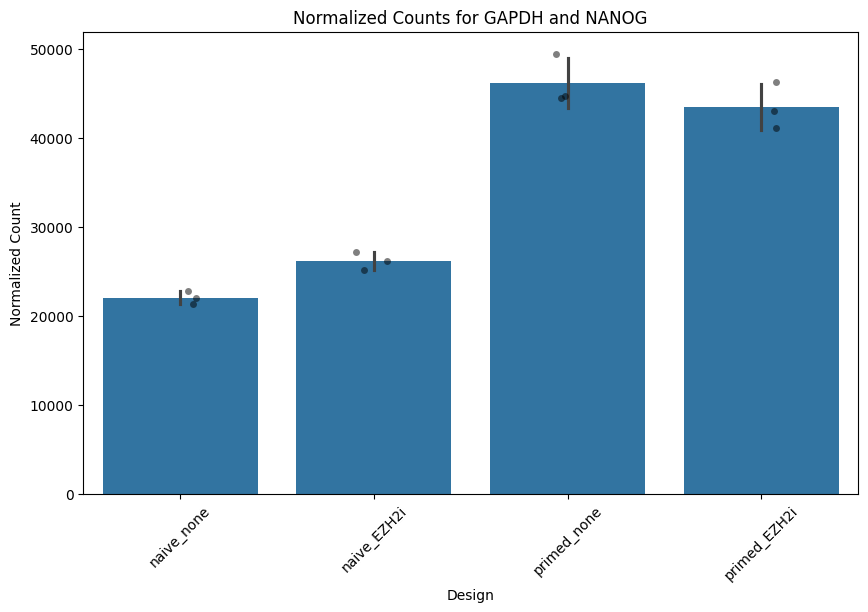

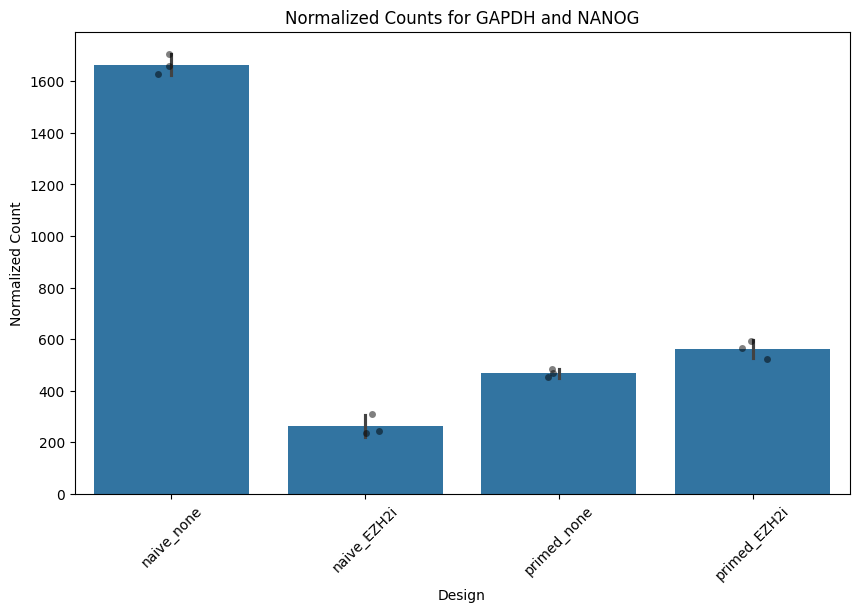

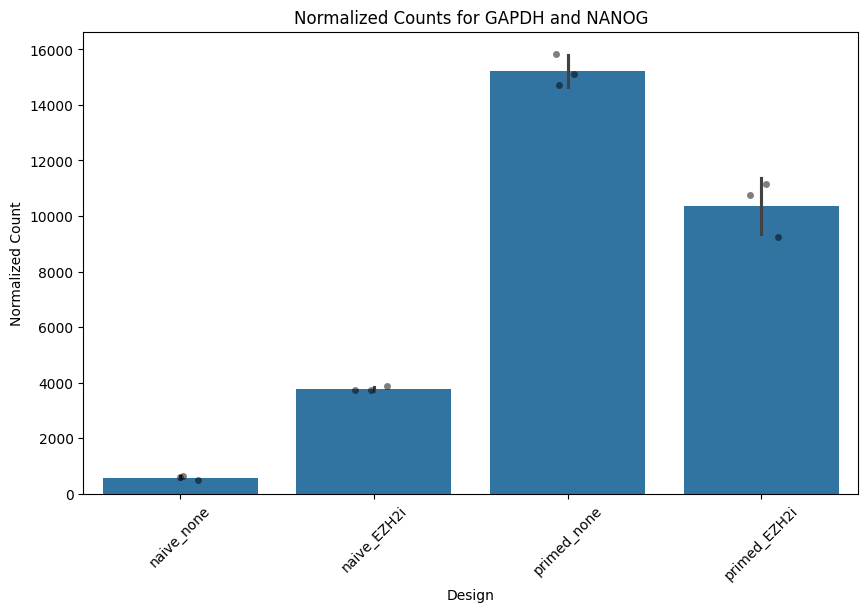

In [22]:

# Plot normalized counts for GAPDH, use bar for mean and error bar for standard deviation across samples of the same design, plot jitter of individual samples on top of the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(data=normed_counts_long[normed_counts_long["gene_id"].isin(["GAPDH"])], x="design", y="normalized_count", ci="sd")
sns.stripplot(data=normed_counts_long[normed_counts_long["gene_id"].isin(["GAPDH"])], x="design", y="normalized_count", color="black", alpha=0.5, jitter=True)
plt.xlabel("Design")
plt.ylabel("Normalized Count")
plt.title("Normalized Counts for GAPDH and NANOG")
plt.xticks(rotation=45)
plt.show()

# Plot normalized counts for NANOG, use bar for mean and error bar for standard deviation across samples of the same design, plot jitter of individual samples on top of the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(data=normed_counts_long[normed_counts_long["gene_id"].isin(["NANOG"])], x="design", y="normalized_count", ci="sd")
sns.stripplot(data=normed_counts_long[normed_counts_long["gene_id"].isin(["NANOG"])], x="design", y="normalized_count", color="black", alpha=0.5, jitter=True)
plt.xlabel("Design")
plt.ylabel("Normalized Count")
plt.title("Normalized Counts for GAPDH and NANOG")
plt.xticks(rotation=45)
plt.show()

# Plot normalized counts for CD24, use bar for mean and error bar for standard deviation across samples of the same design, plot jitter of individual samples on top of the bar plot
plt.figure(figsize=(10, 6))
sns.barplot(data=normed_counts_long[normed_counts_long["gene_id"].isin(["CD24"])], x="design", y="normalized_count", ci="sd")
sns.stripplot(data=normed_counts_long[normed_counts_long["gene_id"].isin(["CD24"])], x="design", y="normalized_count", color="black", alpha=0.5, jitter=True)
plt.xlabel("Design")
plt.ylabel("Normalized Count")
plt.title("Normalized Counts for GAPDH and NANOG")
plt.xticks(rotation=45)
plt.show()

In [23]:
#########################
######   TASK 4   #######
#    Heatmap Figure 2e  #
#########################

# Check out Figure 2e, the figure shows a selection of differentially expressed genes between "Naive" and "Primed" samples,
# using log TPM values

![Figure 2](https://media.springernature.com/full/springer-static/image/art%3A10.1038%2Fs41556-022-00916-w/MediaObjects/41556_2022_916_Fig2_HTML.png)

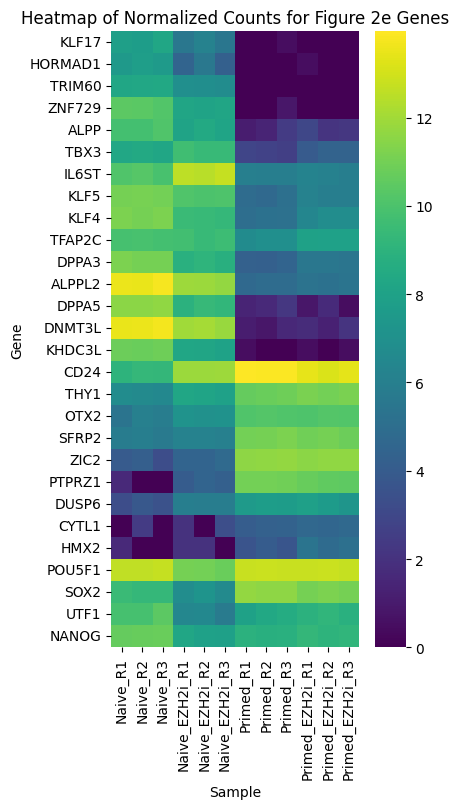

In [94]:
#########################
######   TASK 4   #######
#    Heatmap Figure 2e  #
#########################

genes_2e=["KLF17","HORMAD1","TRIM60","ZNF729","ALPP","TBX3","IL6ST","KLF5","KLF4","TFAP2C","DPPA3","ALPPL2","DPPA5","DNMT3L","KHDC3L","CD24","THY1","OTX2","SFRP2","ZIC2","PTPRZ1","DUSP6","CYTL1","HMX2","POU5F1","SOX2","UTF1","NANOG"]

#from normed_counts_long, subset for the genes in genes_2e and plot a heatmap of the normalized counts for these genes across the samples, group by design
normed_counts_log = normed_counts.reset_index().melt(id_vars=["Name"], var_name="gene_id", value_name="normalized_count")
normed_counts_log["normalized_count"] = np.log2(normed_counts_log["normalized_count"]+1)
normed_counts_log["design"] = normed_counts_log["Name"].map(meta["design"])
normed_counts_2e = normed_counts_log[normed_counts_log["gene_id"].isin(genes_2e)]
normed_counts_2e_pivot = normed_counts_2e.pivot(index="gene_id", columns="Name", values="normalized_count")
# reindex to maintain the original order from genes_2e
normed_counts_2e_pivot = normed_counts_2e_pivot.reindex(genes_2e)
# sort columns by design order: naive_none, naive_EZH2i, primed_none, primed_EZH2i
design_order = ["naive_none","naive_EZH2i","primed_none","primed_EZH2i"]
sorted_columns = sorted(normed_counts_2e_pivot.columns, 
                       key=lambda x: (design_order.index(meta.loc[x, "design"]), x))
normed_counts_2e_pivot = normed_counts_2e_pivot[sorted_columns]
# plot a heatmap of the normalized counts for these genes across the samples, group by design
plt.figure(figsize=(4, 8))
sns.heatmap(normed_counts_2e_pivot, cmap="viridis", yticklabels=True)
plt.title("Heatmap of Normalized Counts for Figure 2e Genes")
plt.xlabel("Sample")
plt.ylabel("Gene")
plt.xticks(rotation=90)
plt.show()


In [30]:
print(dds.obsm["design_matrix"])

                 Intercept  design[T.naive_none]  design[T.primed_EZH2i]  \
Name                                                                       
Naive_R1               1.0                     1                       0   
Naive_R2               1.0                     1                       0   
Naive_R3               1.0                     1                       0   
Naive_EZH2i_R1         1.0                     0                       0   
Naive_EZH2i_R2         1.0                     0                       0   
Naive_EZH2i_R3         1.0                     0                       0   
Primed_R1              1.0                     0                       0   
Primed_R2              1.0                     0                       0   
Primed_R3              1.0                     0                       0   
Primed_EZH2i_R1        1.0                     0                       1   
Primed_EZH2i_R2        1.0                     0                       1   
Primed_EZH2i

In [116]:
#########################
######   TASK 5   #######
#    volcanoe plots     #
#########################

# Extract the results of the DESeq2 analysis for the contrast "Naive_none" vs "Primed_none", which is then
# stored in the "results_df" attribute of the ds object

ds = DeseqStats(dds, contrast=["design", "naive_none", "primed_none"], n_cpus=16)
ds.summary()
naive_vs_primed_raw_lfc = ds.results_df["log2FoldChange"].copy()
ds.lfc_shrink(coeff="design[T.naive_none]")

naive_vs_primed = ds.results_df.copy()


Running Wald tests...
... done in 5.29 seconds.

Fitting MAP LFCs...


Log2 fold change & Wald test p-value: design naive_none vs primed_none
             baseMean  log2FoldChange     lfcSE       stat         pvalue  \
gene_id                                                                     
A1BG        30.878081       -3.504314  0.621501  -5.638464   1.715735e-08   
A1BG-AS1    10.796228       -1.081953  0.624502  -1.732507   8.318335e-02   
A1CF         0.164028       -0.032420  4.595057  -0.007055   9.943707e-01   
A2M         26.315026       -7.136151  1.953044  -3.653862   2.583256e-04   
A2M-AS1      1.510204       -3.251307  2.095288  -1.551723   1.207285e-01   
...               ...             ...       ...        ...            ...   
ZYG11A     159.035116        4.432786  0.163892  27.046990  4.143946e-161   
ZYG11B     281.050682        0.112928  0.110900   1.018290   3.085400e-01   
ZYX       2183.877283        0.396079  0.100180   3.953679   7.695869e-05   
ZZEF1      450.410347        1.438442  0.077860  18.474701   3.300519e-76   
ZZZ3 

... done in 31.84 seconds.



/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


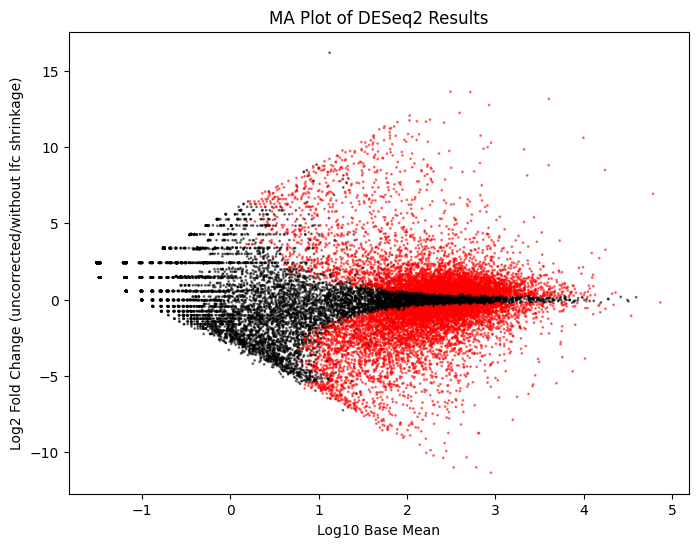

In [77]:
########
# Plot a so-called MA-plot: 
# xaxis is the expression of the gene (log10[baseMean])
# yaxis is the log2 fold change, color points with padj < 0.05 in red and the rest in black

plt.figure(figsize=(8, 6))
colors = np.where(naive_vs_primed["padj"] < 0.01, "red", "black")
plt.scatter(np.log10(naive_vs_primed["baseMean"]), naive_vs_primed_raw_lfc, c=colors, alpha=0.5, s=1)
plt.xlabel("Log10 Base Mean")
plt.ylabel("Log2 Fold Change (uncorrected/without lfc shrinkage)")
plt.title("MA Plot of DESeq2 Results")
plt.show()


/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


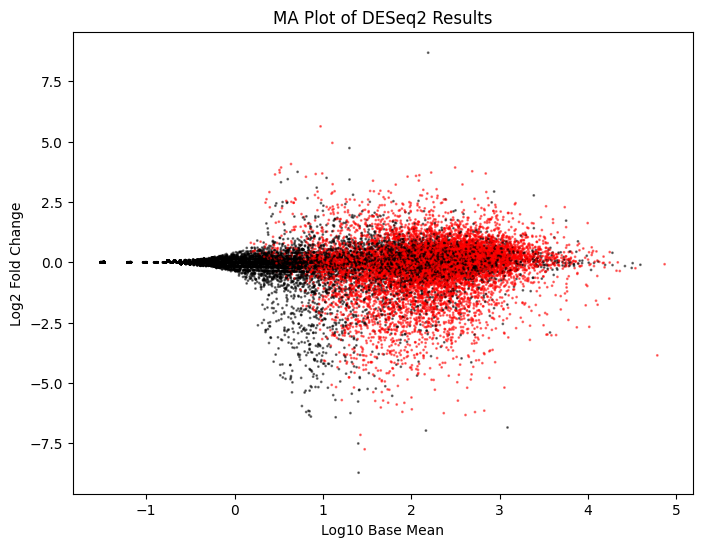

In [83]:
########
# looks like there are very high fold-changes for very lowly expressed genes, 
# this is a common problem in DE analysis, because the fold change is not well defined for low counts.
# Thats why we use a method called "lfcShrink" that shrinks the log fold for small counts


plt.figure(figsize=(8, 6))
colors = np.where(naive_vs_primed["padj"] < 0.01, "red", "black")
plt.scatter(np.log10(naive_vs_primed["baseMean"]), naive_vs_primed["log2FoldChange"], c=colors, alpha=0.5, s=1)
plt.xlabel("Log10 Base Mean")
plt.ylabel("Log2 Fold Change")
plt.title("MA Plot of DESeq2 Results")
plt.show()

/tmp/ipykernel_1847/1257253147.py:18: RuntimeWarning: divide by zero encountered in log10
  y = -np.log10(naive_vs_primed.loc[gene, "padj"])


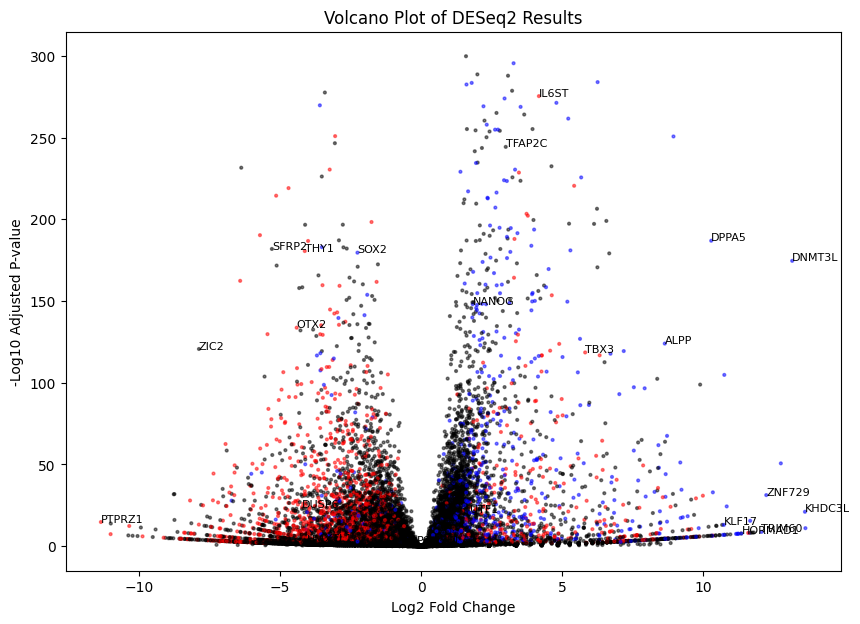

In [119]:
#######
# Volcano plot:
# xaxis is the log2 fold change, yaxis is the -log10 of the adjusted p-value

#print Volcano plot plot of the results, color points with padj < 0.05 and |lfc|>1 in red and the rest in black
plt.figure(figsize=(10, 7))
colors = np.where((naive_vs_primed["padj"] < 0.01) & (naive_vs_primed["log2FoldChange"] > 1), "blue", np.where((naive_vs_primed["padj"] < 0.01) & (naive_vs_primed["log2FoldChange"] < -1), "red", "black"))
plt.scatter(naive_vs_primed_raw_lfc, -np.log10(naive_vs_primed["padj"]), c=colors, alpha=0.5, s=4)
plt.xlabel("Log2 Fold Change")
plt.ylabel("-Log10 Adjusted P-value")
plt.title("Volcano Plot of DESeq2 Results")

# Add text labels for genes in genes_2e
texts = []
for gene in genes_2e:
    if gene in naive_vs_primed.index:
        x = naive_vs_primed_raw_lfc.loc[gene]
        y = -np.log10(naive_vs_primed.loc[gene, "padj"])
        texts.append(plt.text(x, y, gene, fontsize=8))
plt.show()


### Remember:

| Measuremen      | Meaning                                |
| --------------- | ---------------------------------------|
| p-value         | evidence against null                  |
| padj-valu       | p after correction for multiple testing|
| log2FC          | estimated effect size                  |
| shrunken log2FC | stabilized plausible effect size       |


In [ ]:
### Now lets look at Figure 2a! comparing EZH2i vs none in the "Naive" condition, extract the results for this contrast and plot a volcano plot as well.

![Figure 3](https://media.springernature.com/full/springer-static/image/art%3A10.1038%2Fs41556-022-00916-w/MediaObjects/41556_2022_916_Fig3_HTML.png)

In [80]:
#########################
######   TASK    #######
#    volcanoe plots     #
#########################

# Extract the results of the DESeq2 analysis for the contrast "Naive_EZH2i" vs "Naive_none", which is then
# stored in the "results_df" attribute of the ds object
print(dds.obsm["design_matrix"]) # check the design matrix to see how the contrasts are defined
ds = DeseqStats(dds, contrast=["design", "naive_EZH2i", "naive_none"], n_cpus=16)
ds.summary()
EZH2i_vs_naive_raw_lfc = ds.results_df.copy()
ds.lfc_shrink(coeff="design[T.naive_none]")

EZH2i_vs_naive = ds.results_df.copy()


                 Intercept  design[T.naive_none]  design[T.primed_EZH2i]  \
Name                                                                       
Naive_R1               1.0                     1                       0   
Naive_R2               1.0                     1                       0   
Naive_R3               1.0                     1                       0   
Naive_EZH2i_R1         1.0                     0                       0   
Naive_EZH2i_R2         1.0                     0                       0   
Naive_EZH2i_R3         1.0                     0                       0   
Primed_R1              1.0                     0                       0   
Primed_R2              1.0                     0                       0   
Primed_R3              1.0                     0                       0   
Primed_EZH2i_R1        1.0                     0                       1   
Primed_EZH2i_R2        1.0                     0                       1   
Primed_EZH2i

Running Wald tests...
... done in 6.40 seconds.

Fitting MAP LFCs...


Log2 fold change & Wald test p-value: design naive_EZH2i vs naive_none
             baseMean  log2FoldChange     lfcSE       stat        pvalue  \
gene_id                                                                    
A1BG        30.878081        1.605420  0.735297   2.183363  2.900907e-02   
A1BG-AS1    10.796228        1.682458  0.702650   2.394446  1.664551e-02   
A1CF         0.164028        0.489783  4.918717   0.099575  9.206815e-01   
A2M         26.315026        2.932455  2.122058   1.381892  1.670050e-01   
A2M-AS1      1.510204        0.489794  2.843867   0.172228  8.632581e-01   
...               ...             ...       ...        ...           ...   
ZYG11A     159.035116       -2.108800  0.182161 -11.576604  5.414878e-31   
ZYG11B     281.050682        0.194481  0.132526   1.467490  1.422429e-01   
ZYX       2183.877283       -0.018819  0.103489  -0.181849  8.557012e-01   
ZZEF1      450.410347       -0.273564  0.092560  -2.955523  3.121392e-03   
ZZZ3       331.01

... done in 32.99 seconds.



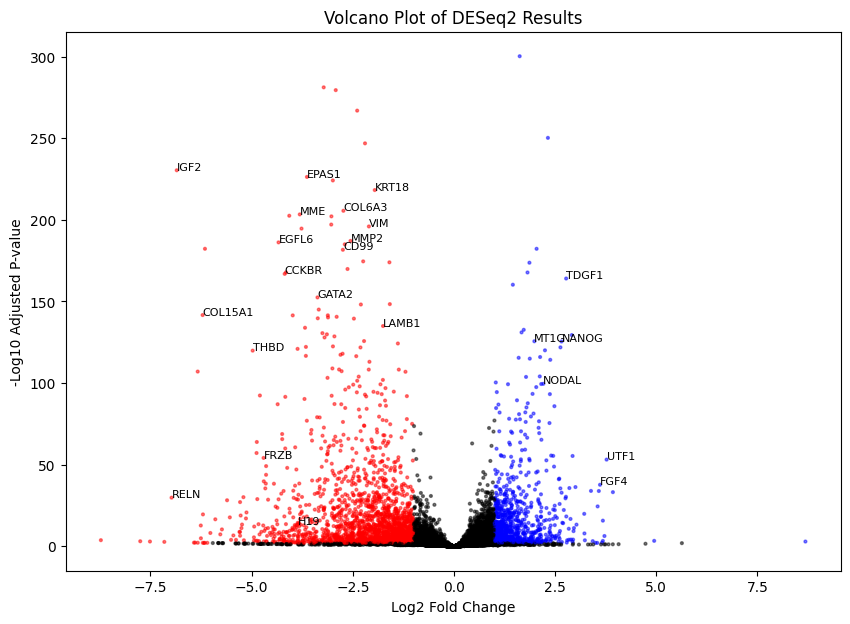

In [120]:
# genes to mark as in volcanoe plot
genes_3a =  ["KRT18",  "H19", "IGF2", "EPAS2", "COL6A3", "MME",
    "VIM", "MMP2", "EGFL6", "CCKBR", "GATA2", "COL15A1", "CD99","EPAS1",
    "LAMB1", "THBD", "FRZB",  "RELN", "TDGF1", "MT1G","DDPA5","NODAL","NANOG","UTF1",
    "FGF4"]


#######
# Volcano plot:
# xaxis is the log2 fold change, yaxis is the -log10 of the adjusted p-value

#print Volcano plot plot of the results, color points with padj < 0.05 and |lfc|>1 in red and the rest in black
plt.figure(figsize=(10, 7))
colors = np.where((EZH2i_vs_naive["padj"] < 0.01) & (EZH2i_vs_naive["log2FoldChange"] > 1), "blue", np.where((EZH2i_vs_naive["padj"] < 0.01) & (EZH2i_vs_naive["log2FoldChange"] < -1), "red", "black"))
plt.scatter(EZH2i_vs_naive["log2FoldChange"], -np.log10(EZH2i_vs_naive["padj"]), c=colors, alpha=0.5, s=4)
plt.xlabel("Log2 Fold Change")
plt.ylabel("-Log10 Adjusted P-value")
plt.title("Volcano Plot of DESeq2 Results")

# Add text labels for genes in genes_2e
texts = []
for gene in genes_3a:
    if gene in EZH2i_vs_naive.index:
        x = EZH2i_vs_naive.loc[gene, "log2FoldChange"]
        y = -np.log10(EZH2i_vs_naive.loc[gene, "padj"])
        texts.append(plt.text(x, y, gene, fontsize=8))
plt.show()

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


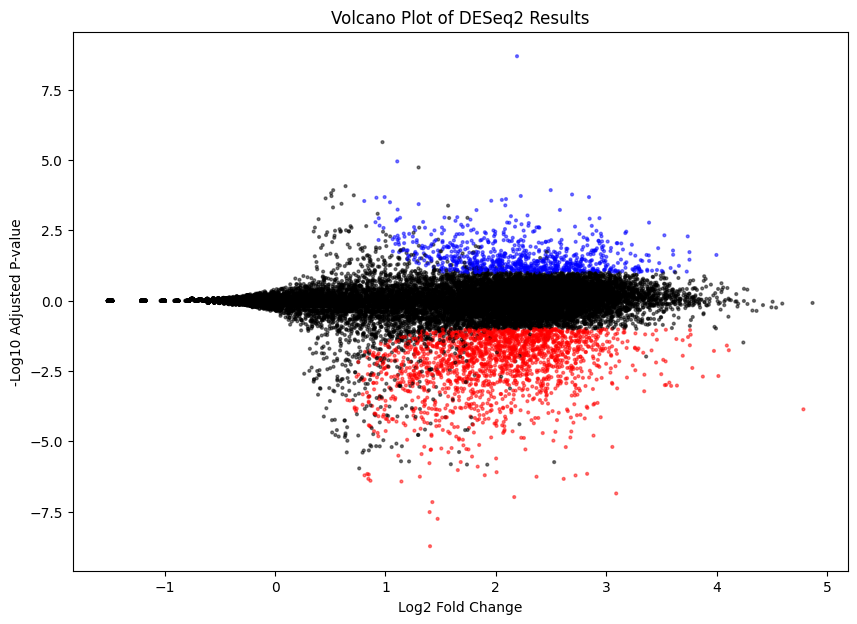

In [69]:
#######
# Volcano plot:
# xaxis is the log2 fold change, yaxis is the -log10 of the adjusted p-value

#print Volcano plot plot of the results, color points with padj < 0.05 and |lfc|>1 in red and the rest in black
plt.figure(figsize=(10, 7))
colors = np.where((EZH2i_vs_naive["padj"] < 0.01) & (EZH2i_vs_naive["log2FoldChange"] > 1), "blue", np.where((EZH2i_vs_naive["padj"] < 0.01) & (EZH2i_vs_naive["log2FoldChange"] < -1), "red", "black"))
plt.scatter(np.log10(EZH2i_vs_naive["baseMean"]), EZH2i_vs_naive["log2FoldChange"], c=colors, alpha=0.5, s=4)
plt.xlabel("Log2 Fold Change")
plt.ylabel("-Log10 Adjusted P-value")
plt.title("Volcano Plot of DESeq2 Results")
plt.show()

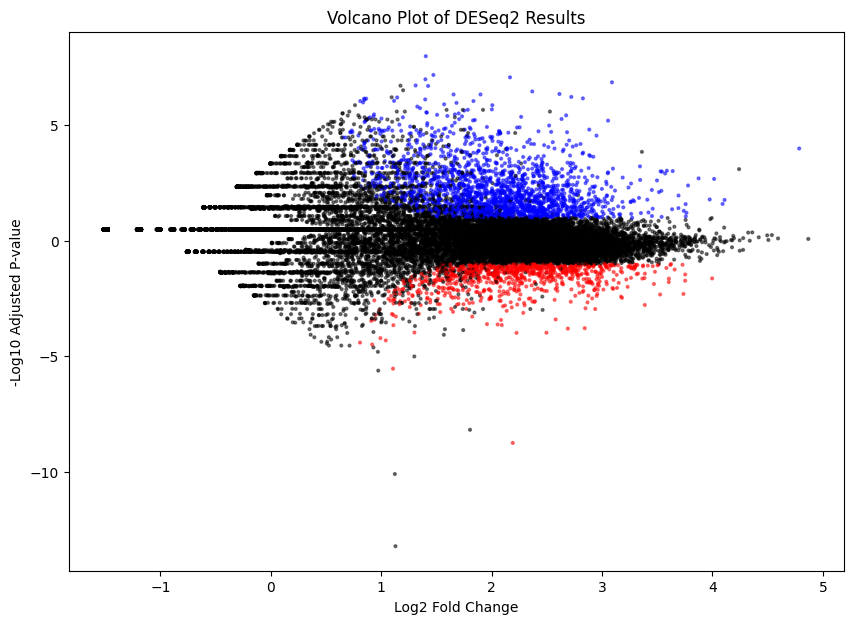

In [68]:
#######
# Volcano plot:
# xaxis is the log2 fold change, yaxis is the -log10 of the adjusted p-value

#print Volcano plot plot of the results, color points with padj < 0.05 and |lfc|>1 in red and the rest in black
plt.figure(figsize=(10, 7))
colors = np.where((EZH2i_vs_naive_raw_lfc["padj"] < 0.01) & (EZH2i_vs_naive_raw_lfc["log2FoldChange"] > 1), "blue", np.where((EZH2i_vs_naive_raw_lfc["padj"] < 0.01) & (EZH2i_vs_naive_raw_lfc["log2FoldChange"] < -1), "red", "black"))
plt.scatter(np.log10(EZH2i_vs_naive_raw_lfc["baseMean"]), EZH2i_vs_naive_raw_lfc["log2FoldChange"], c=colors, alpha=0.5, s=4)
plt.xlabel("Log2 Fold Change")
plt.ylabel("-Log10 Adjusted P-value")
plt.title("Volcano Plot of DESeq2 Results")
plt.show()

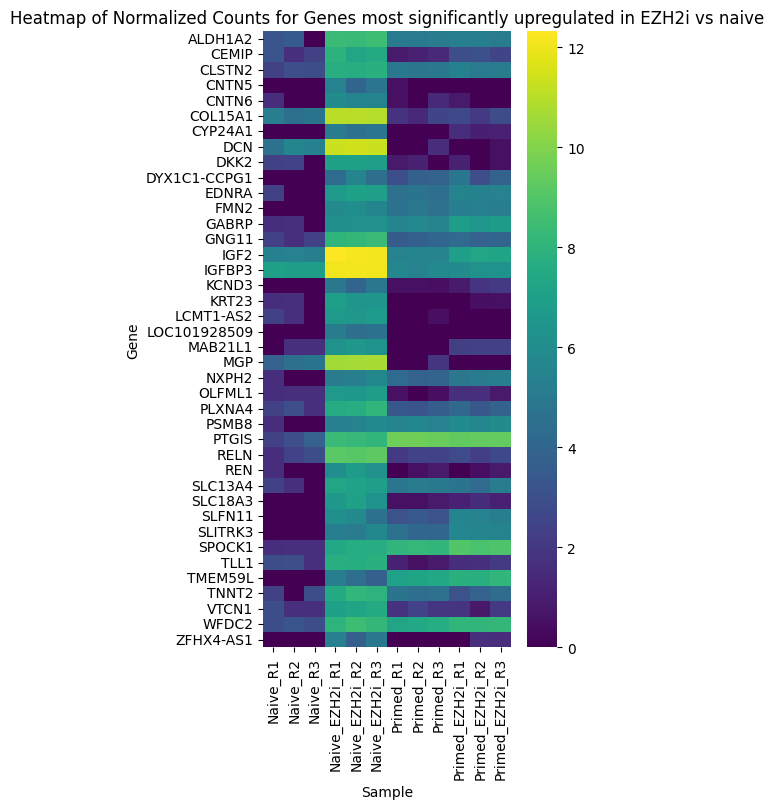

In [ ]:

topEZH2i = EZH2i_vs_naive[(EZH2i_vs_naive["padj"] < 0.01) & (EZH2i_vs_naive["log2FoldChange"] < -5)]

#from normed_counts_long, subset for the genes in genes_2e and plot a heatmap of the normalized counts for these genes across the samples, group by design
normed_counts_3a = normed_counts_log[normed_counts_log["gene_id"].isin(topEZH2i.index.tolist())]
normed_counts_3a_pivot = normed_counts_3a.pivot(index="gene_id", columns="Name", values="normalized_count")

# sort columns by design order: naive_none, naive_EZH2i, primed_none, primed_EZH2i
design_order = ["naive_none","naive_EZH2i","primed_none","primed_EZH2i"]
sorted_columns = sorted(normed_counts_3a_pivot.columns, 
                       key=lambda x: (design_order.index(meta.loc[x, "design"]), x))
normed_counts_3a_pivot = normed_counts_3a_pivot[sorted_columns]
# plot a heatmap of the normalized counts for these genes across the samples, group by design
plt.figure(figsize=(4, 8))
sns.heatmap(normed_counts_3a_pivot, cmap="viridis", yticklabels=True)
plt.title("Heatmap of Normalized Counts for Genes most significantly upregulated in EZH2i vs naive")
plt.xlabel("Sample")
plt.ylabel("Gene")
plt.xticks(rotation=90)
plt.show()

In [ ]:
#######
# GENE SET ENRICHMENT ANALYSIS
# get naive- and primed-specific genes-sets 
%pip install gprofiler-official

sigUp = EZH2i_vs_naive[(EZH2i_vs_naive["padj"] < 0.01) & (EZH2i_vs_naive["log2FoldChange"] > 2)]

# get significantly downregulated genes
sigDown = EZH2i_vs_naive[(EZH2i_vs_naive["padj"] < 0.01) & (EZH2i_vs_naive["log2FoldChange"] < -2)]

# perform gene set enrichment analysis with gprofiler for the upregulated genes, use the "gost" function and specify the organism as "hsapiens"
from gprofiler.gprofiler import GProfiler

gpo = GProfiler(return_dataframe=True)

enrichment_up = gpo.profile(query=sigUp.index.tolist(), organism="hsapiens")
enrichment_down = gpo.profile(query=sigDown.index.tolist(), organism="hsapiens")

###
print(enrichment_up.head())

  source              native  \
0     WP           WP:WP5568   
1  GO:BP          GO:0032501   
2   REAC   REAC:R-HSA-452723   
3   REAC  REAC:R-HSA-1181150   
4   KEGG          KEGG:04350   

                                                name   p_value  significant  \
0  SOX genes and their influence on neurogenesis ...  0.000983         True   
1                   multicellular organismal process  0.003406         True   
2  Transcriptional regulation of pluripotent stem...  0.004427         True   
3                                 Signaling by NODAL  0.005333         True   
4                         TGF-beta signaling pathway  0.011034         True   

                                         description  term_size  query_size  \
0  SOX genes and their influence on neurogenesis ...         28          83   
1  "Any biological process, occurring at the leve...       7337         122   
2  Transcriptional regulation of pluripotent stem...         22          72   
3               

In [ ]:
print(enrichment_down.head())
